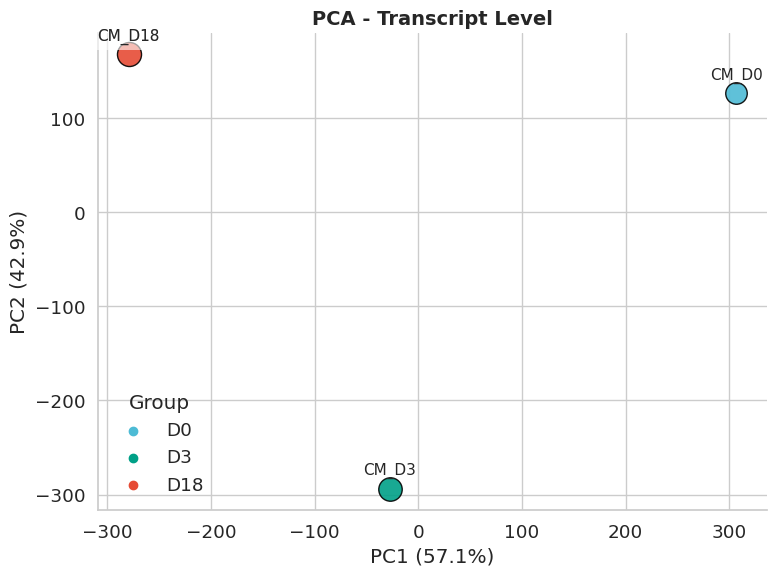

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from adjustText import adjust_text


# -------------------------
# 1. Carregar dados
# -------------------------
df = pd.read_csv("/transcript_count_matrix.csv")

# médias
df["CM_D0"]  = df[["CM_D0_R1", "CM_D0_R2"]].mean(axis=1)
df["CM_D3"]  = df[["CM_D3_R1", "CM_D3_R2"]].mean(axis=1)
df["CM_D18"] = df[["CM_D18_R1", "CM_D18_R2"]].mean(axis=1)

# filtrar ENST
df = df[df["transcript_id"].str.startswith("ENST")]

# filtro leve
df = df[df[["CM_D0","CM_D3","CM_D18"]].sum(axis=1) > 10]

# -------------------------
# 2. Preparar matriz
# -------------------------
df_pca = df.set_index("transcript_id")[["CM_D0","CM_D3","CM_D18"]]
df_pca = df_pca.T

# log transform
df_log = np.log2(df_pca + 1)

# -------------------------
# 3. PCA
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# variância explicada
var_exp = pca.explained_variance_ratio_ * 100

# -------------------------
# 4. Metadata
# -------------------------
samples = df_log.index

meta = pd.DataFrame({
    "sample": samples,
    "group": ["D0", "D3", "D18"],   # ajuste conforme necessário
    "library_size": [80, 95, 100]   # exemplo (pode usar soma real)
})

# -------------------------
# 5. Plot
# -------------------------
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(8,6))

# cores bonitas
palette = {
    "D0": "#4DBBD5",
    "D3": "#00A087",
    "D18": "#E64B35"
}

# scatter
for i, sample in enumerate(samples):
    plt.scatter(
        X_pca[i,0],
        X_pca[i,1],
        s=meta.loc[i, "library_size"] * 3,
        color=palette[meta.loc[i, "group"]],
        edgecolor="black",
        alpha=0.9
    )

# labels com ajuste automático
texts = []
for i, sample in enumerate(samples):
    plt.text(
        X_pca[i,0],
        X_pca[i,1] + 15,
        sample,
        fontsize=11,
        ha='center'
    )

adjust_text(
    texts,
    expand_points=(2,2),
    expand_text=(2,2),
    arrowprops=dict(arrowstyle="-", color='gray', lw=0.5)
)

# eixos
plt.xlabel(f"PC1 ({var_exp[0]:.1f}%)")
plt.ylabel(f"PC2 ({var_exp[1]:.1f}%)")

plt.title("PCA - Transcript Level", fontsize=14, weight="bold")

plt.text(
    X_pca[i,0],
    X_pca[i,1] + 15,
    sample,
    fontsize=11,
    ha='center',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
)

# legenda manual
for group in meta["group"].unique():
    plt.scatter([], [], color=palette[group], label=group)

plt.legend(title="Group", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()